In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_csv('../Datasets/placement.csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\anush\AppData\Local\Temp\ipykernel_15812\3576195541.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\anush\AppData\Local\Temp\ipykernel_15812\3576195541.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


Text(0.5, 1.0, 'placement_exam_marks')

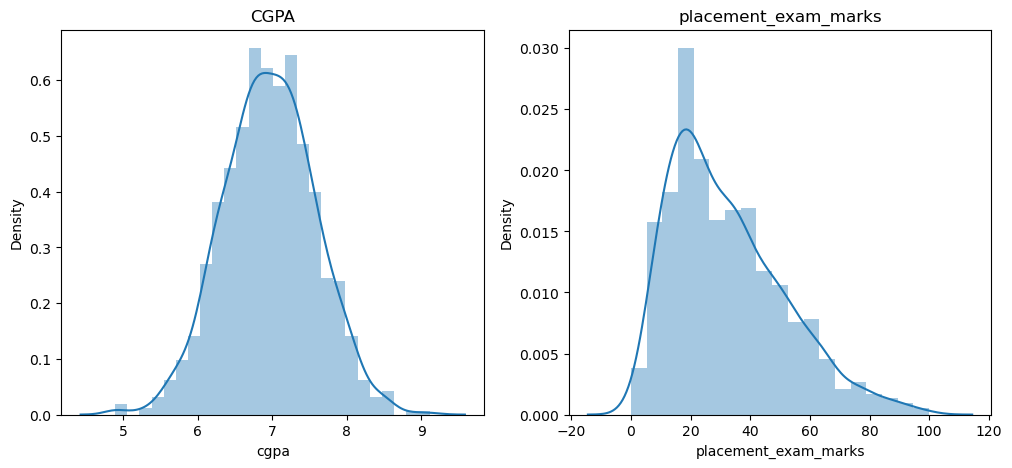

In [6]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.distplot(df['cgpa'])
plt.title('CGPA')

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])
plt.title('placement_exam_marks')

In [7]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

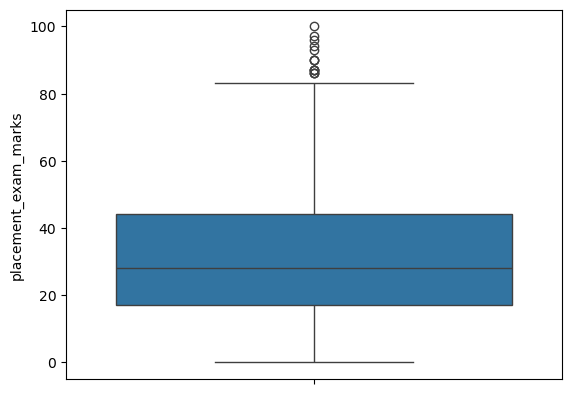

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [11]:
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [14]:
iqr=percentile75-percentile25
iqr

27.0

In [15]:
upper_limit=percentile75+1.*iqr
lower_limit=percentile25-1.5*iqr

In [18]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
98,8.12,76.0,0
114,6.30,77.0,1
134,6.33,93.0,0
157,7.07,81.0,1
162,7.80,90.0,0
182,6.87,76.0,0
222,6.97,78.0,0


In [19]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


#### Trimming 

In [22]:
new_df=df[(df['placement_exam_marks'] < upper_limit) ]

In [23]:
new_df.shape

(958, 3)

C:\Users\anush\AppData\Local\Temp\ipykernel_15812\1813148216.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\anush\AppData\Local\Temp\ipykernel_15812\1813148216.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


Text(0.5, 1.0, 'After Boxplot placement_exam_marks')

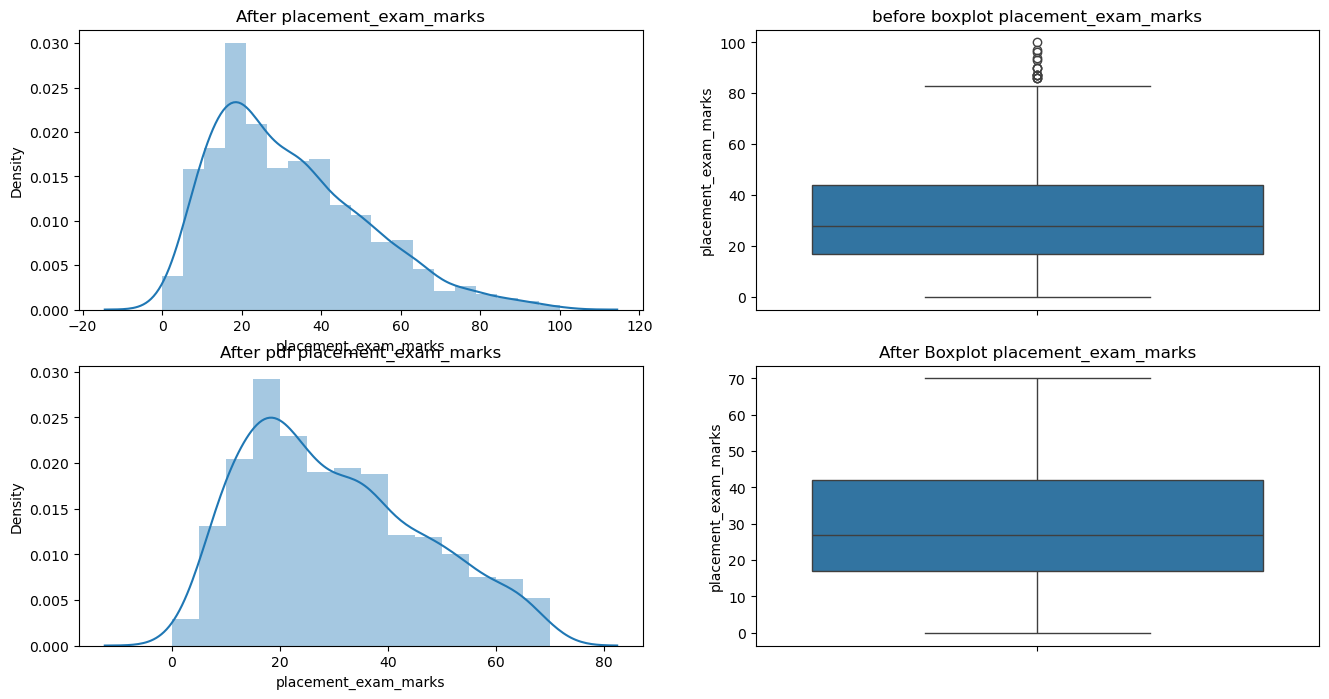

In [25]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])
plt.title('After placement_exam_marks')
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.title('before boxplot placement_exam_marks')

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])
plt.title('After pdf placement_exam_marks')
plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])
plt.title('After Boxplot placement_exam_marks')

In [28]:
new_df_copy=df.copy()

new_df_copy['placement_exam_marks']=np.where(
                            new_df_copy['placement_exam_marks']>upper_limit,
                            upper_limit,
                            np.where(
                                new_df_copy['placement_exam_marks']<lower_limit,
                                lower_limit,
                                new_df_copy['placement_exam_marks']
                            )
)

C:\Users\anush\AppData\Local\Temp\ipykernel_15812\396776838.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\anush\AppData\Local\Temp\ipykernel_15812\396776838.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_copy['placement_exam_marks'])


Text(0.5, 1.0, 'After Boxplot placement_exam_marks')

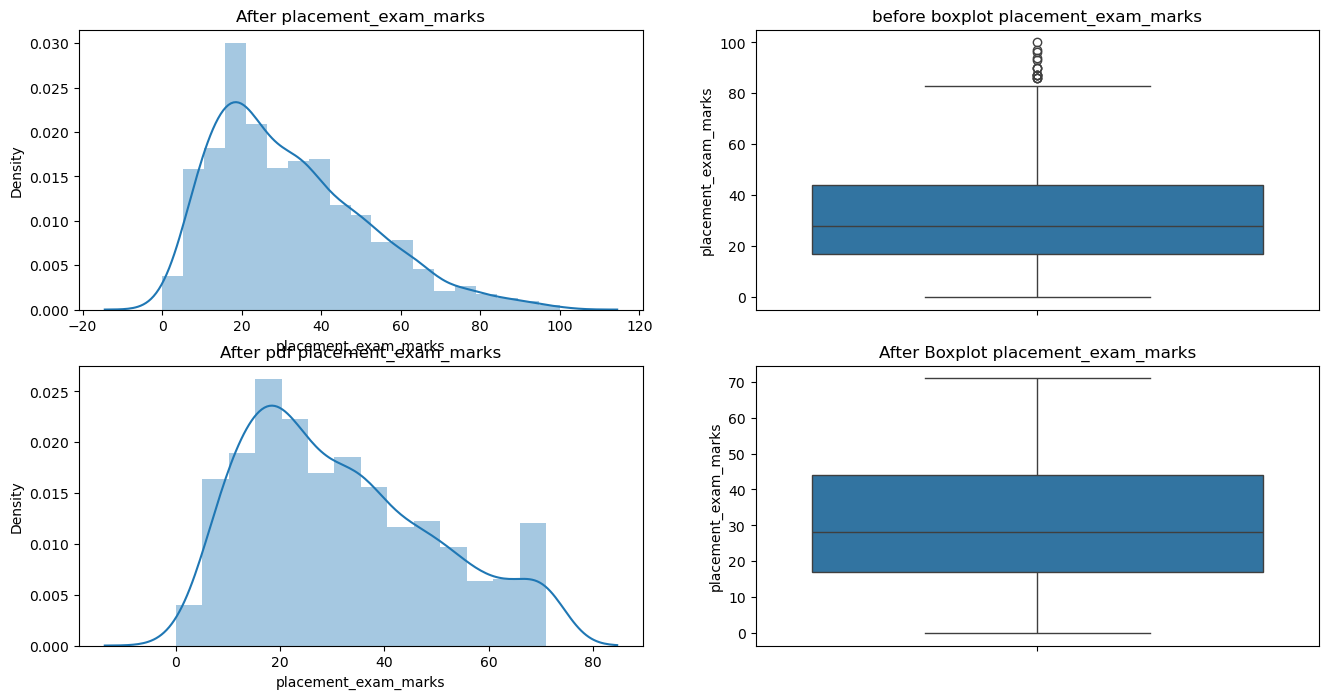

In [29]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])
plt.title('After placement_exam_marks')
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.title('before boxplot placement_exam_marks')

plt.subplot(2,2,3)
sns.distplot(new_df_copy['placement_exam_marks'])
plt.title('After pdf placement_exam_marks')
plt.subplot(2,2,4)
sns.boxplot(new_df_copy['placement_exam_marks'])
plt.title('After Boxplot placement_exam_marks')